# SMAD Pre-check 1: U_posterior vs Drift Alignment

This notebook loads `results/tables/smad_alignment_check.json` and visualizes the posterior slow-mode autocorrelations, drift projections, and rank sensitivity curves.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'results').exists():
    REPO_ROOT = REPO_ROOT.parent

RESULT_PATH = REPO_ROOT / 'results' / 'tables' / 'smad_alignment_check.json'
FIGURE_DIR = REPO_ROOT / 'results' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with RESULT_PATH.open() as f:
    result = json.load(f)

posterior = result['posterior_pca']
rank_results = result['rank_results']
autocorr = np.asarray(posterior['lag1_autocorrelation_retained'], dtype=float)
slow_order = np.asarray(posterior['slow_pc_order'], dtype=int)
curve_ranks = [int(r) for r in result['curve_ranks']]

plt.style.use('seaborn-v0_8-whitegrid')
print(f"Loaded {RESULT_PATH.relative_to(REPO_ROOT)}")
print(f"Retained PCs: {posterior['retained_components']}")
print(f"Reported ranks: {result['reported_ranks']}")

Loaded results/tables/smad_alignment_check.json
Retained PCs: 38
Reported ranks: [3, 5, 10]


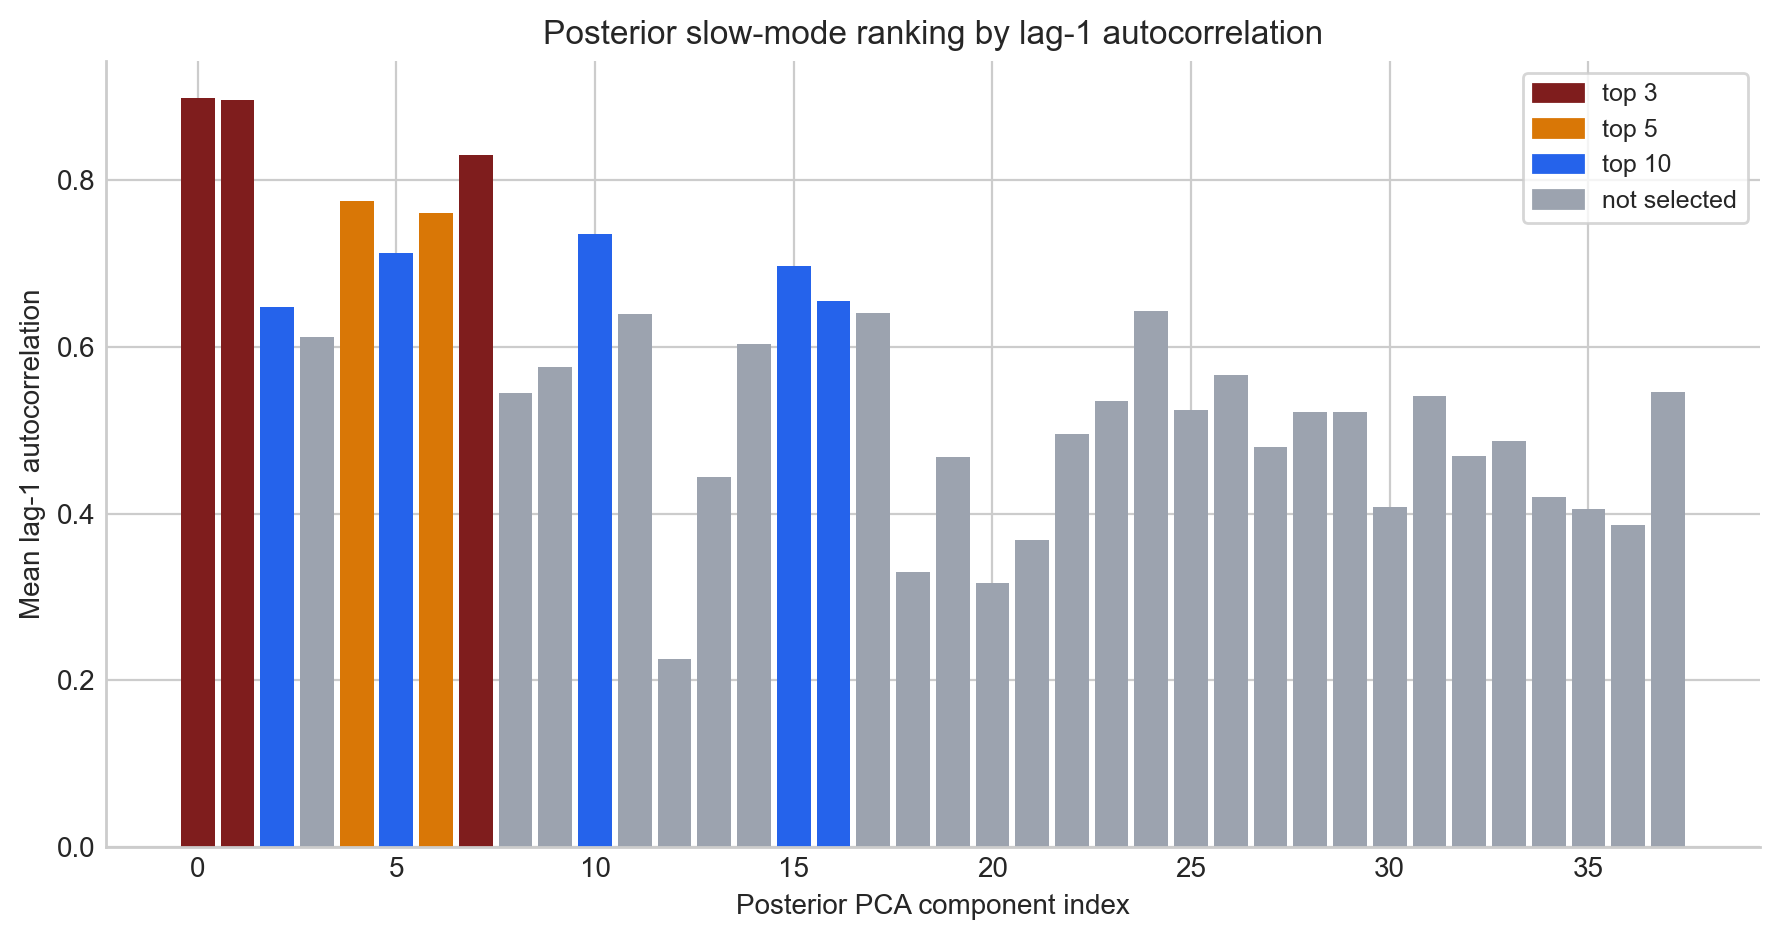

Saved results/figures/smad_alignment_autocorr.pdf


In [2]:
pc_index = np.arange(autocorr.size)
top3 = set(slow_order[:3])
top5 = set(slow_order[:5])
top10 = set(slow_order[:10])

colors = []
for pc in pc_index:
    if pc in top3:
        colors.append('#7f1d1d')
    elif pc in top5:
        colors.append('#d97706')
    elif pc in top10:
        colors.append('#2563eb')
    else:
        colors.append('#9ca3af')

fig, ax = plt.subplots(figsize=(9, 4.8), dpi=200)
ax.bar(pc_index, autocorr, color=colors, width=0.85)
ax.set_xlabel('Posterior PCA component index')
ax.set_ylabel('Mean lag-1 autocorrelation')
ax.set_title('Posterior slow-mode ranking by lag-1 autocorrelation')
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color='#7f1d1d', label='top 3'),
    plt.Rectangle((0, 0), 1, 1, color='#d97706', label='top 5'),
    plt.Rectangle((0, 0), 1, 1, color='#2563eb', label='top 10'),
    plt.Rectangle((0, 0), 1, 1, color='#9ca3af', label='not selected'),
]
ax.legend(handles=legend_handles, frameon=True, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
autocorr_path = FIGURE_DIR / 'smad_alignment_autocorr.pdf'
fig.savefig(autocorr_path, bbox_inches='tight')
plt.show()
print(f"Saved {autocorr_path.relative_to(REPO_ROOT)}")

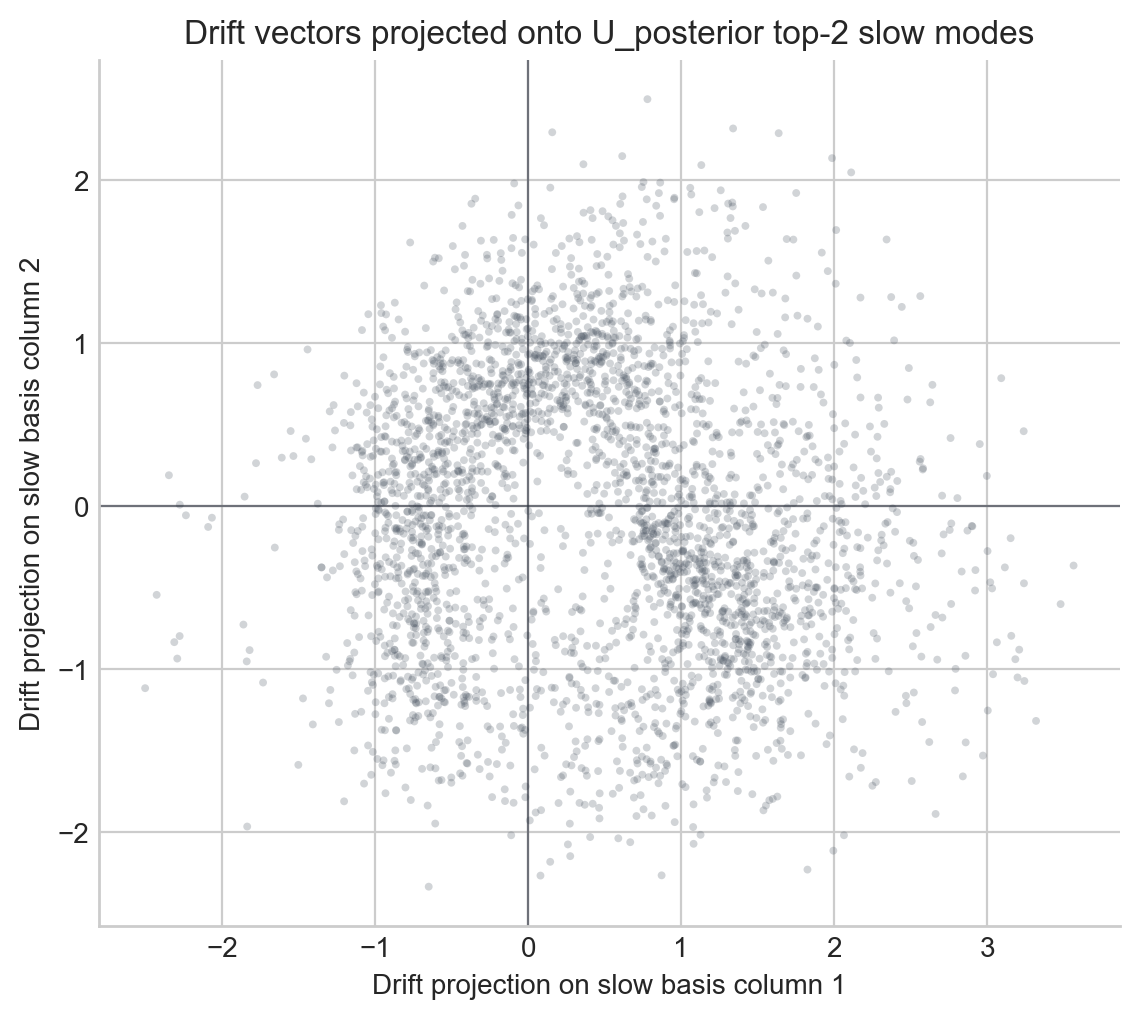

Saved results/figures/smad_alignment_drift_projection.pdf


In [3]:
proj = np.asarray(result['drift_projection_u_posterior_r2'], dtype=float)

fig, ax = plt.subplots(figsize=(5.8, 5.2), dpi=200)
ax.scatter(proj[:, 0], proj[:, 1], s=8, alpha=0.25, color='#4b5563', edgecolors='none')
ax.axhline(0, color='#111827', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='#111827', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Drift projection on slow basis column 1')
ax.set_ylabel('Drift projection on slow basis column 2')
ax.set_title('Drift vectors projected onto U_posterior top-2 slow modes')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
scatter_path = FIGURE_DIR / 'smad_alignment_drift_projection.pdf'
fig.savefig(scatter_path, bbox_inches='tight')
plt.show()
print(f"Saved {scatter_path.relative_to(REPO_ROOT)}")

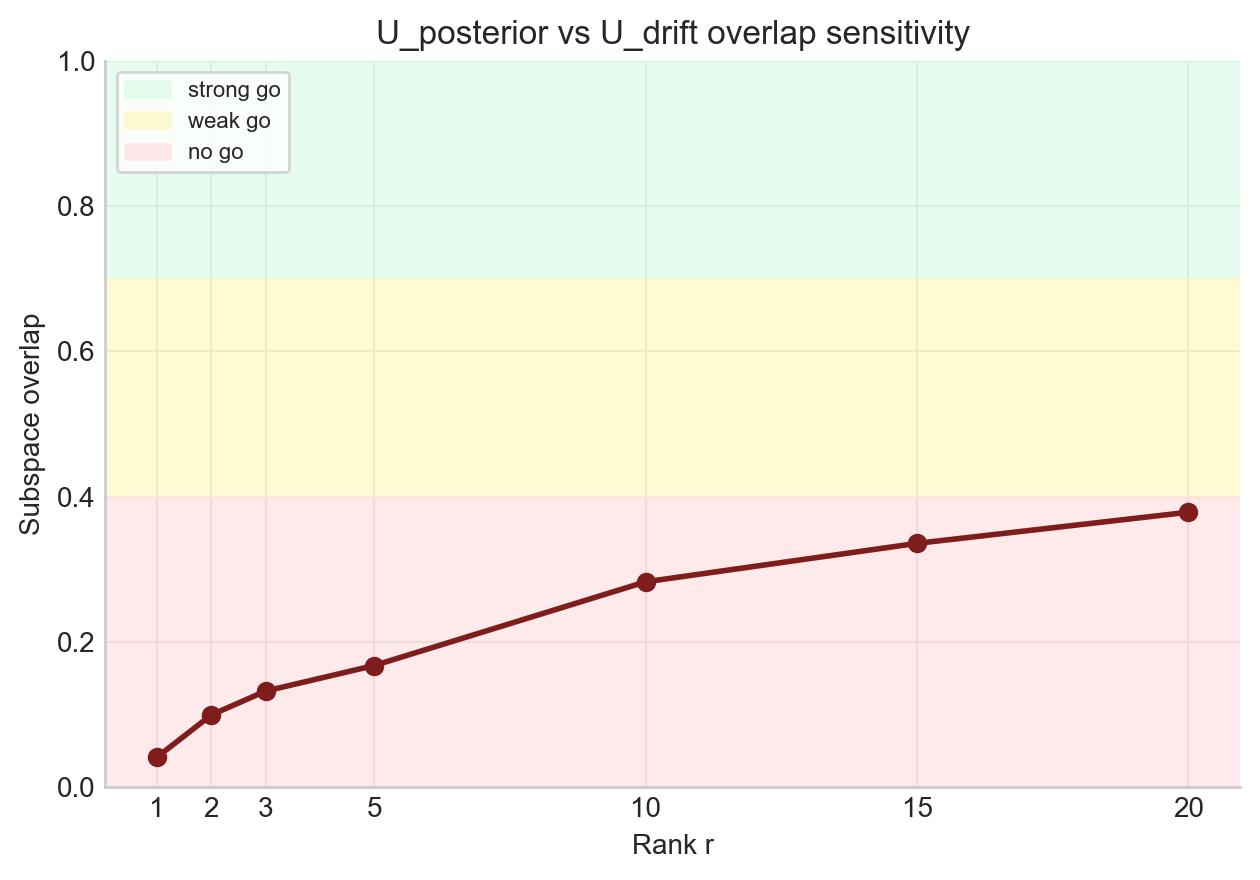

Saved results/figures/smad_alignment_overlap_vs_rank.pdf


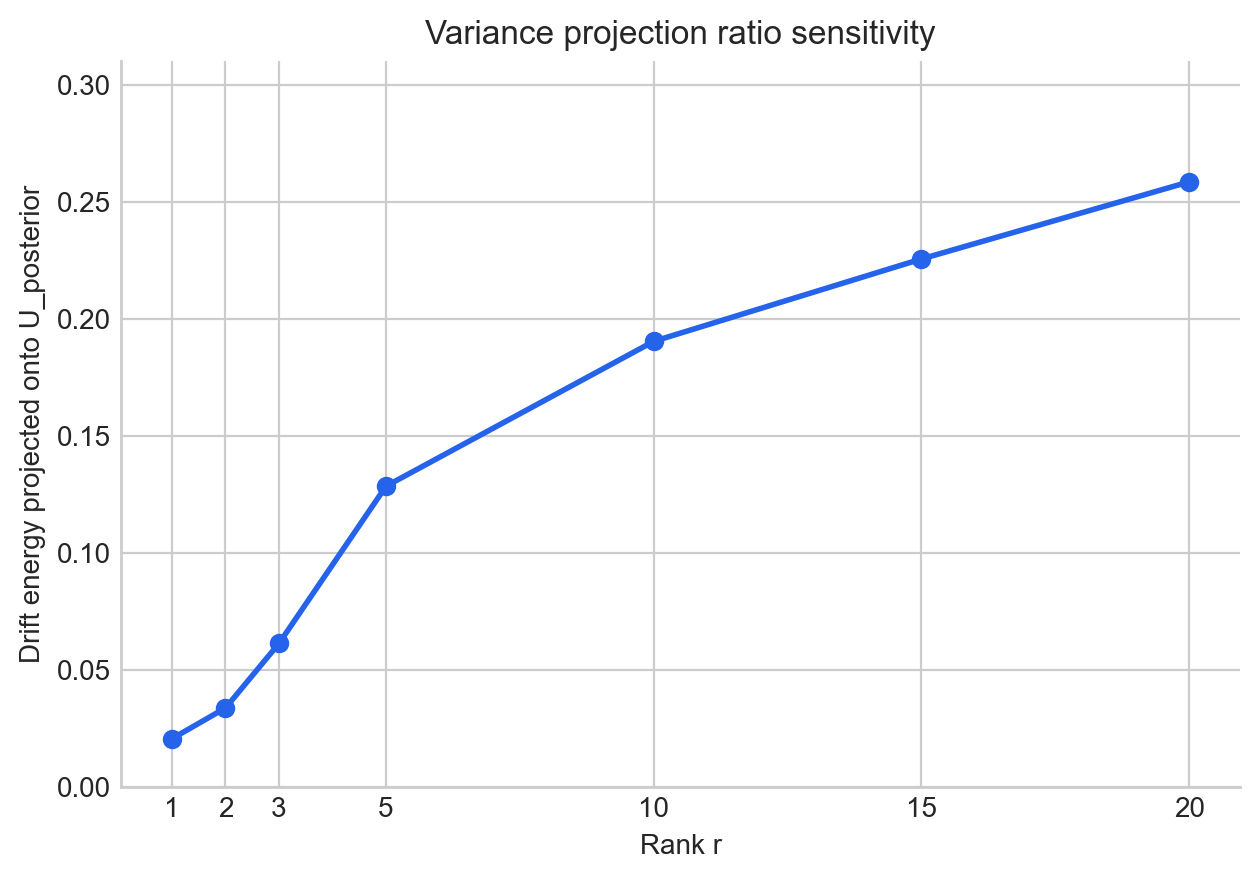

Saved results/figures/smad_alignment_variance_ratio_vs_rank.pdf


In [4]:
overlap = np.array([rank_results[str(r)]['overlap'] for r in curve_ranks], dtype=float)
variance_ratio = np.array(
    [rank_results[str(r)]['variance_projection_ratio'] for r in curve_ranks],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(6.4, 4.5), dpi=200)
ax.plot(curve_ranks, overlap, marker='o', color='#7f1d1d', linewidth=2)
ax.axhspan(0.7, 1.0, color='#dcfce7', alpha=0.7, label='strong go')
ax.axhspan(0.4, 0.7, color='#fef9c3', alpha=0.7, label='weak go')
ax.axhspan(0.0, 0.4, color='#fee2e2', alpha=0.7, label='no go')
ax.set_ylim(0, 1)
ax.set_xticks(curve_ranks)
ax.set_xlabel('Rank r')
ax.set_ylabel('Subspace overlap')
ax.set_title('U_posterior vs U_drift overlap sensitivity')
ax.legend(loc='upper left', frameon=True, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
overlap_path = FIGURE_DIR / 'smad_alignment_overlap_vs_rank.pdf'
fig.savefig(overlap_path, bbox_inches='tight')
plt.show()
print(f"Saved {overlap_path.relative_to(REPO_ROOT)}")

fig, ax = plt.subplots(figsize=(6.4, 4.5), dpi=200)
ax.plot(curve_ranks, variance_ratio, marker='o', color='#2563eb', linewidth=2)
ax.set_ylim(0, max(0.05, min(1.0, variance_ratio.max() * 1.2)))
ax.set_xticks(curve_ranks)
ax.set_xlabel('Rank r')
ax.set_ylabel('Drift energy projected onto U_posterior')
ax.set_title('Variance projection ratio sensitivity')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
variance_path = FIGURE_DIR / 'smad_alignment_variance_ratio_vs_rank.pdf'
fig.savefig(variance_path, bbox_inches='tight')
plt.show()
print(f"Saved {variance_path.relative_to(REPO_ROOT)}")